In [1]:
import matplotlib.pyplot as plt  # Graphics
from matplotlib import colors
import seaborn  # Graphics
import geopandas  # Spatial data manipulation
import pandas  # Tabular data manipulation
import rioxarray  # Surface data manipulation
import xarray  # Surface data manipulation
from pysal.explore import esda  # Exploratory Spatial analytics
from pysal.lib import weights  # Spatial weights
import contextily  # Background tiles

c:\Users\User\.ipython\.venv\Lib\site-packages\spaghetti\network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
import os
# Check current working directory
print("Current working directory:", os.getcwd())

# List files in the current directory
print("Files in directory:", os.listdir())

Current working directory: c:\Users\User\.ipython\.venv\geopandas-coures-files\geopandas-coures-files\Spatial_Data_Analysis
Files in directory: ['Analyis2.ipynb', 'Analysis1.ipynb', 'Analysis3.ipynb', 'brexit_vote.csv', 'DSd.cpg', 'DSd.dbf', 'DSd.prj', 'DSd.sbn', 'DSd.sbx', 'DSd.shp', 'DSd.shp.xml', 'DSd.shx', 'Kandy_data.cpg', 'Kandy_data.dbf', 'Kandy_data.prj', 'Kandy_data.sbn', 'Kandy_data.sbx', 'Kandy_data.shp', 'Kandy_data.shp.xml', 'Kandy_data.shx', 'local_authority_districts.geojson', 'Nuwara_Data.cpg', 'Nuwara_Data.dbf', 'Nuwara_Data.prj', 'Nuwara_Data.sbn', 'Nuwara_Data.sbx', 'Nuwara_Data.shp', 'Nuwara_Data.shp.xml', 'Nuwara_Data.shx', 'Population_data.cpg', 'Population_data.dbf', 'Population_data.prj', 'Population_data.sbn', 'Population_data.sbx', 'Population_data.shp', 'Population_data.shp.xml', 'Population_data.shx', 'Testing.cpg', 'Testing.dbf', 'Testing.prj', 'Testing.sbn', 'Testing.sbx', 'Testing.shp', 'Testing.shp.xml', 'Testing.shx', 'Values.csv']


In [3]:
ref = pandas.read_csv(
    "Values.csv", index_col="OBJECTID"
)
ref.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 1 to 810
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LST_2015   810 non-null    float64
 1   LST_2020   810 non-null    float64
 2   NDVI_2015  810 non-null    float64
dtypes: float64(3)
memory usage: 25.3 KB


In [4]:
lads = geopandas.read_file(
    "Testing.shp"
)
lads.head()

,OBJECTID,Details,geometry
0,1,1.0,"POLYGON ((7.42731 51.46058, 7.42231 51.46058, ..."
1,2,2.0,"POLYGON ((7.43231 51.46058, 7.42731 51.46058, ..."
2,3,3.0,"POLYGON ((7.43731 51.46058, 7.43231 51.46058, ..."
3,4,4.0,"POLYGON ((7.44231 51.46058, 7.43731 51.46058, ..."
4,5,5.0,"POLYGON ((7.44731 51.46058, 7.44231 51.46058, ..."


In [5]:
lads = geopandas.read_file(
    "Testing.shp"
).set_index("OBJECTID")
lads.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 810 entries, 1 to 810
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Details   810 non-null    float64 
 1   geometry  810 non-null    geometry
dtypes: float64(1), geometry(1)
memory usage: 19.0 KB


In [6]:
db = (
    geopandas.GeoDataFrame(
        lads.join(ref[["LST_2020"]]), crs=lads.crs
    )
    .to_crs(epsg=3857)[
        ["Details", "LST_2020","geometry"]
    ]
    .dropna()
)
db.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 810 entries, 1 to 810
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Details   810 non-null    float64 
 1   LST_2020  810 non-null    float64 
 2   geometry  810 non-null    geometry
dtypes: float64(2), geometry(1)
memory usage: 25.3 KB


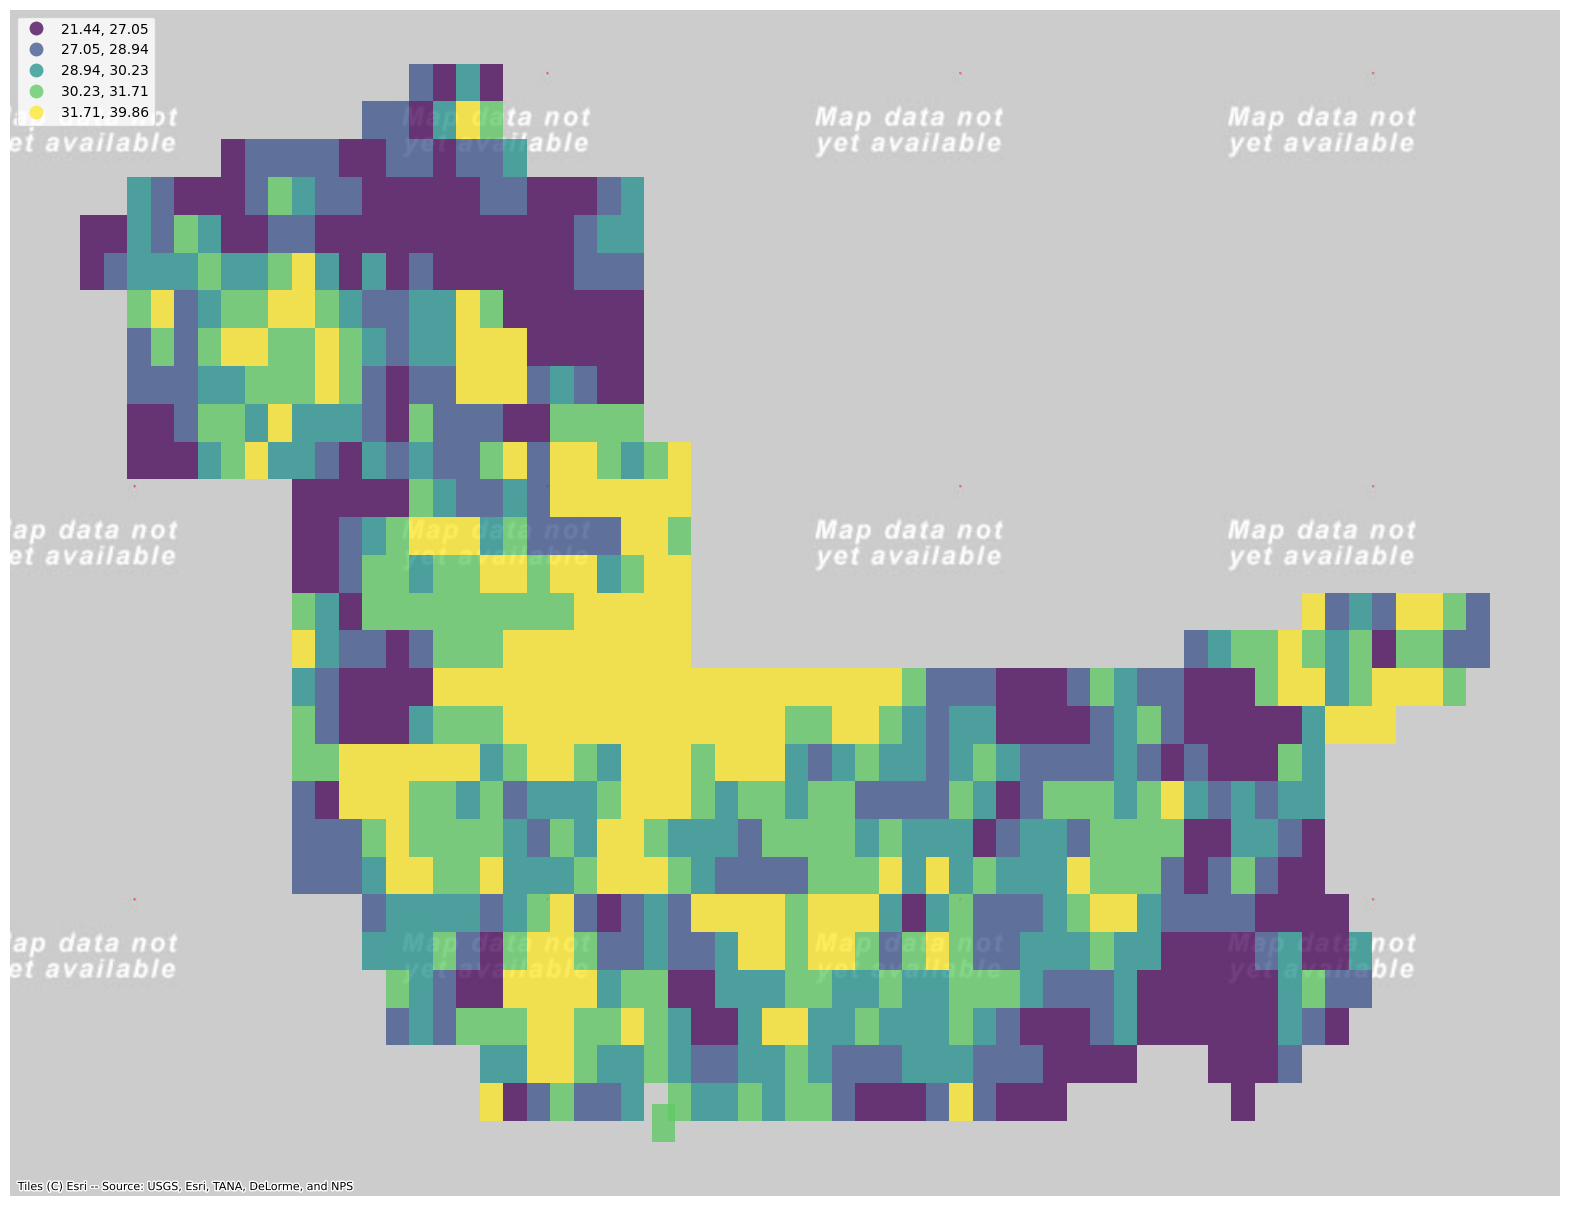

In [7]:
f, ax = plt.subplots(1, figsize=(20, 20))
db.plot(
    column="LST_2020",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
contextily.add_basemap(
    ax,
    crs=db.crs,
    source=contextily.providers.Esri.WorldTerrain,
)
ax.set_axis_off()

In [8]:
# Generate W from the GeoDataFrame
w = weights.KNN.from_dataframe(db, k=8)
# Row-standardization
w.transform = "R"

In [9]:
db["LST_2020_lag"] = weights.spatial_lag.lag_spatial(
    w, db["LST_2020"]
)

In [10]:
db.loc[[5,10], ["LST_2020", "LST_2020_lag"]]

,LST_2020,LST_2020_lag
OBJECTID,,
5,28.7947,29.720012
10,29.3818,29.418062


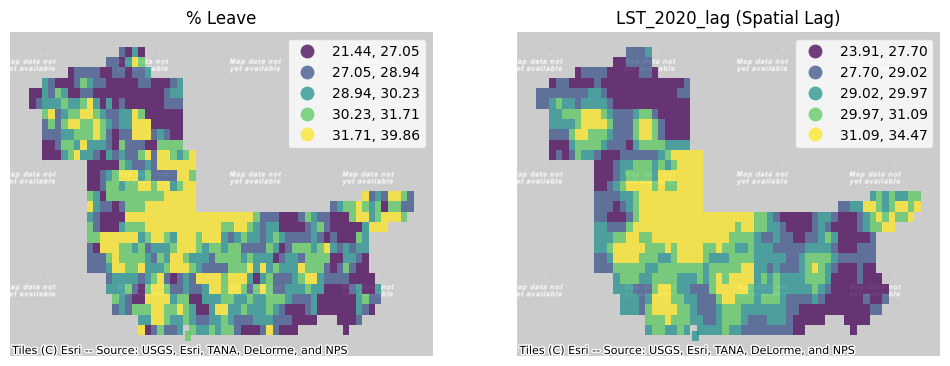

In [11]:
f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs

db.plot(
    column="LST_2020",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax1,
)
ax1.set_axis_off()
ax1.set_title("% Leave")
contextily.add_basemap(
    ax1,
    crs=db.crs,
    source=contextily.providers.Esri.WorldTerrain,
)

db.plot(
    column="LST_2020_lag",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    ax=ax2,
)
ax2.set_axis_off()
ax2.set_title("LST_2020_lag (Spatial Lag)")
contextily.add_basemap(
    ax2,
    crs=db.crs,
    source=contextily.providers.Esri.WorldTerrain,
)

plt.show()

The spatial lag operator is one of the most common and direct applications of spatial weights matrices (called 
 formally) in spatial analysis. The mathematical definition is the product of 
 and the vector of a given variable. Conceptually, the spatial lag captures the behavior of a variable in the immediate surroundings of each location; in that respect, it is akin to a local smoother of a variable.

In [38]:
db["UH_area"] = (db["LST_2020"] > 30).astype(int)
db[["LST_2020", "UH_area"]].tail()

,LST_2020,UH_area
OBJECTID,,
806,30.9144,1
807,27.9621,0
808,26.4052,0
809,29.5772,0
810,26.5915,0


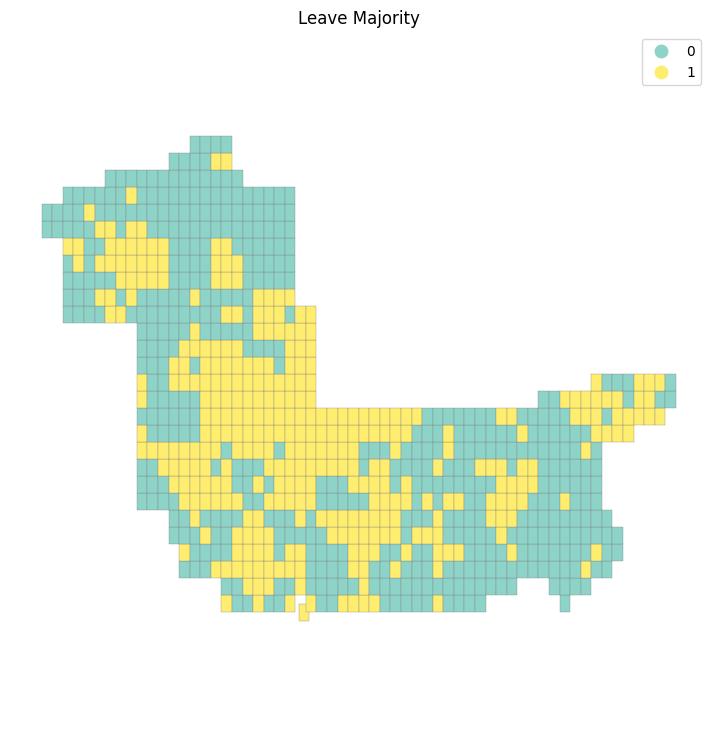

In [39]:
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    ax=ax,
    column="UH_area",
    categorical=True,
    legend=True,
    edgecolor="0.5",
    linewidth=0.25,
    cmap="Set3",
    figsize=(9, 9),
)
ax.set_axis_off()
ax.set_title("Leave Majority")
plt.axis("equal")
plt.show()

In [14]:
w.transform
w.transform = "O"
w.transform


'O'

In [15]:
db["LST_2020_std"] = db["LST_2020"] - db["LST_2020"].mean()
db["LST_2020_lag_std"] = weights.lag_spatial(
    w, db["LST_2020_std"]
)

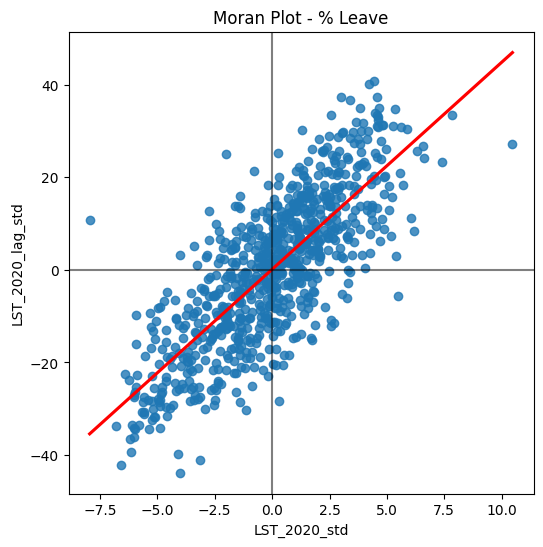

In [16]:
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="LST_2020_std",
    y="LST_2020_lag_std",
    ci=None,
    data=db,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - % Leave")
plt.show()

In [17]:
w.transform = "R"
moran = esda.moran.Moran(db["LST_2020"], w)


In [18]:
moran.I

np.float64(0.5589148929619344)

In [19]:
moran.p_sim

np.float64(0.001)

In [20]:
import pysal
import splot

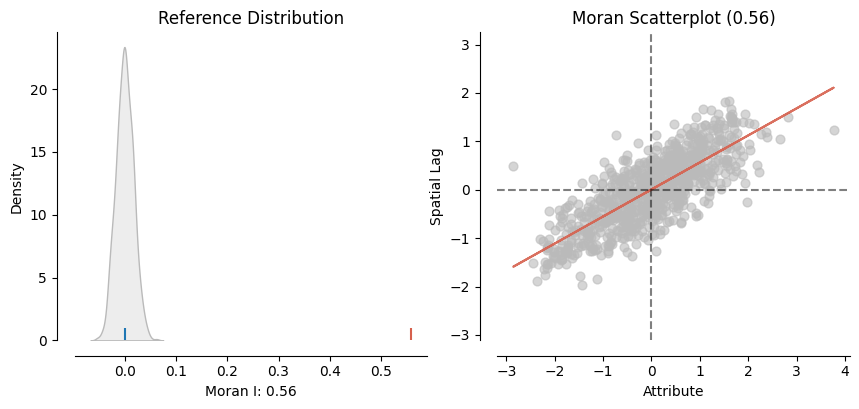

In [67]:
from splot.esda import plot_moran
plot_moran(moran);


In [21]:
lisa = esda.moran.Moran_Local(db["LST_2020"], w)

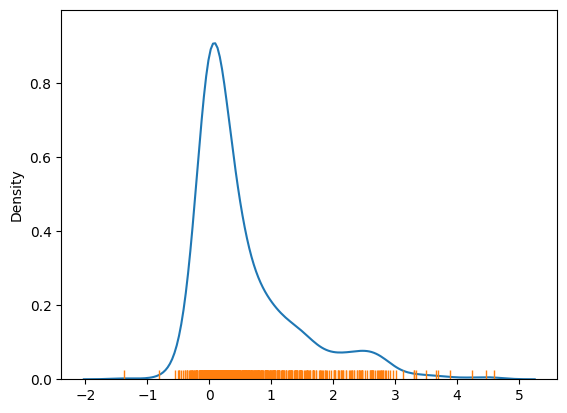

In [22]:
# Draw KDE line
ax = seaborn.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
seaborn.rugplot(lisa.Is, ax=ax);

In [23]:
from splot import esda as esdaplot

In [40]:
db["w_LST_2020"] = weights.lag_spatial(w, db['LST_2020'])

In [41]:
db["LST_2020_std"] = db["LST_2020"] - db["LST_2020"].mean()
db["w_LST_2020_std"] = weights.lag_spatial(w, db['LST_2020_std'])

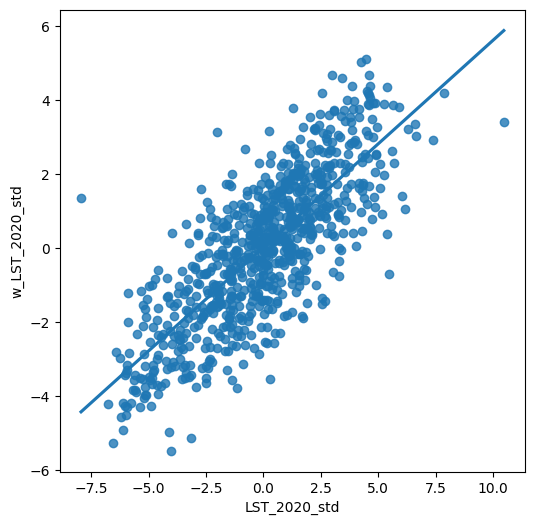

In [42]:
# Set up the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
seaborn.regplot(
    x="LST_2020_std", y="w_LST_2020_std", data=db, ci=None
)
plt.show()

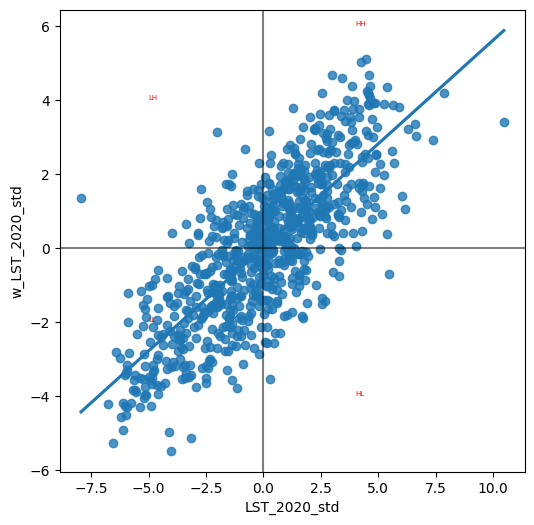

In [46]:
# Set up the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
seaborn.regplot(
    x="LST_2020_std", y="w_LST_2020_std", data=db, ci=None
)
# Add vertical and horizontal lines
plt.axvline(0, c="k", alpha=0.5)
plt.axhline(0, c="k", alpha=0.5)
# Add text labels for each quadrant
plt.text(4, 6, "HH", fontsize=5, c="r")
plt.text(4, -4, "HL", fontsize=5, c="r")
plt.text(-5, 4, "LH", fontsize=5, c="r")
plt.text(-5, -2, "LL", fontsize=5, c="r")
# Display
plt.show()

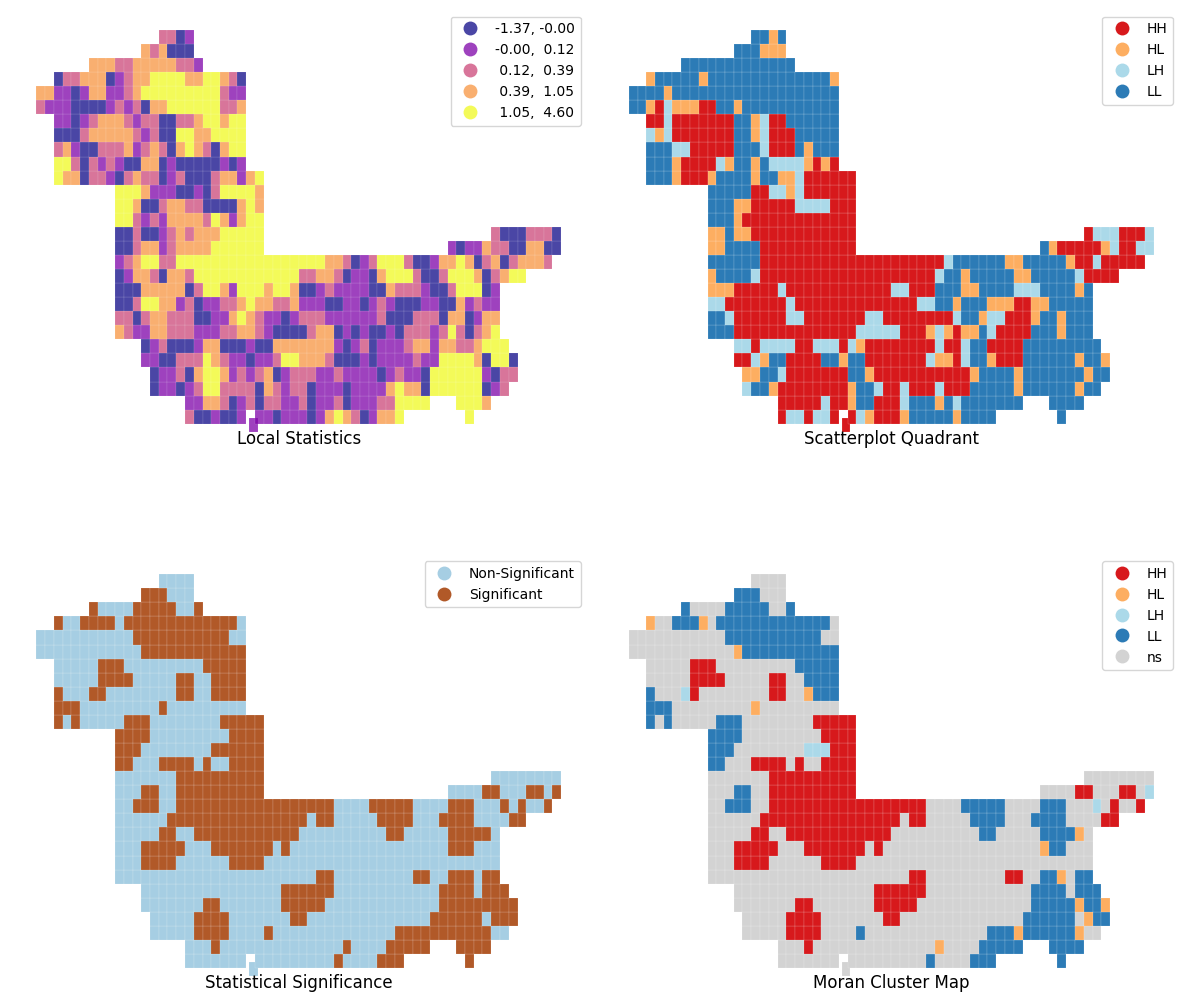

In [43]:
# Set up figure and axes
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Choropleth of local statistics
# Grab first axis in the figure
ax = axs[0]
# Assign new column with local statistics on-the-fly
db.assign(
    Is=lisa.Is
    # Plot choropleth of local statistics
).plot(
    column="Is",
    cmap="plasma",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.75,
    legend=True,
    ax=ax,
)

# Subplot 2 #
# Quadrant categories
# Grab second axis of local statistics
ax = axs[1]
# Plot Quadrant colors (note to ensure all polygons are assigned a
# quadrant, we "trick" the function by setting significance level to
# 1 so all observations are treated as "significant" and thus assigned
# a quadrant color
esdaplot.lisa_cluster(lisa, db, p=1, ax=ax)

# Subplot 3 #
# Significance map
# Grab third axis of local statistics
ax = axs[2]
#
# Find out significant observations
labels = pandas.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=db.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
db.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[3]
# Plot Quadrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, db, p=0.05, ax=ax)

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    ax.set_title(
        [
            "Local Statistics",
            "Scatterplot Quadrant",
            "Statistical Significance",
            "Moran Cluster Map",
        ][i],
        y=0,
    )
# Tight layout to minimize in-between white space
f.tight_layout()

# Display the figure
plt.show()

In [25]:
lisa.q[:10]

array([1, 2, 2, 1, 2, 2, 1, 1, 1, 2])

In [26]:
counts = pandas.value_counts(lisa.q)
counts

C:\Users\User\AppData\Local\Temp\ipykernel_1148\3518240389.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  counts = pandas.value_counts(lisa.q)


1    338
3    295
4     89
2     88
Name: count, dtype: int64

In [27]:
(lisa.p_sim < 0.05).sum() * 100 / len(lisa.p_sim)

np.float64(41.60493827160494)

In [28]:
# Assign pseudo P-values to `db`
db["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
db["sig"] = sig
# Print top of the table to inspect
db[["sig", "p-sim"]].head()

,sig,p-sim
OBJECTID,,
1,0,0.348
2,0,0.110
3,0,0.137
4,0,0.500
5,0,0.397


In [29]:
# Print bottom of the table to inspect
db[["sig", "p-sim"]].tail()

,sig,p-sim
OBJECTID,,
806,0,0.178
807,0,0.106
808,0,0.266
809,0,0.138
810,0,0.380


In [30]:
# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
db["labels"] = pandas.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=db.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
db["labels"].head()

OBJECTID
1    Non-Significant
2    Non-Significant
3    Non-Significant
4    Non-Significant
5    Non-Significant
Name: labels, dtype: object

In [31]:
db["labels"].value_counts()

labels
Non-Significant    473
HH                 160
LL                 157
HL                  14
LH                   6
Name: count, dtype: int64